<div style="background:linear-gradient(135deg,#512E5F 0%,#7D3C98 100%);padding:40px 36px 32px 36px;border-radius:10px;margin-bottom:8px;">
  <p style="color:#D7BDE2;font-size:13px;margin:0 0 6px 0;letter-spacing:2px;">CURSO 8 · MÓDULO 4 · CLASE 10</p>
  <h1 style="color:white;font-size:36px;margin:0 0 10px 0;font-weight:700;">PCA — Componentes Principales y SVD</h1>
  <p style="color:#D7BDE2;font-size:16px;margin:0 0 24px 0;font-style:italic;">Reducción de dimensionalidad · Varianza explicada · Scree plot · Biplot</p>
  <hr style="border-color:#A569BD;margin:0 0 20px 0;">
  <p style="color:#F5EEF8;font-size:13px;margin:0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; <strong>Módulo 4:</strong> PCA &nbsp;·&nbsp; 2 horas</p>
</div>

## Objetivos
| # | Al terminar podés |
|---|-------------------|
| 1 | Derivar PCA desde la eigendecomposición de la covarianza Σ̂ |
| 2 | Entender la relación entre eigendecomposición y SVD |
| 3 | Construir e interpretar el scree plot |
| 4 | Visualizar un biplot: observaciones y features juntos |
| 5 | Aplicar PCA para decorrelacionar un dataset |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi':110,'font.size':11,'axes.spines.top':False,'axes.spines.right':False})
SEED=42; np.random.seed(SEED)
print('✅ Setup listo')

✅ Setup listo


---
## 1. ¿Qué hace PCA?

PCA encuentra las **direcciones de máxima varianza** en los datos.

- **PC1** → dirección de mayor varianza del dataset
- **PC2** → mayor varianza, ortogonal a PC1
- **PCₖ** → ortogonal a todas las anteriores

Resultado: variables **decorrelacionadas** (covarianzas = 0 en el nuevo espacio).

In [2]:
# Motivación: datos correlacionados → PCA los decorrelaciona
np.random.seed(SEED)
n=200
Sigma=np.array([[4.0, 3.0, 1.0],
                [3.0, 3.0, 0.5],
                [1.0, 0.5, 1.0]])
X=np.random.multivariate_normal([0,0,0], Sigma, n)

print('Correlaciones ORIGINALES (variables correlacionadas):')
print(pd.DataFrame(np.corrcoef(X.T),
      columns=['x1','x2','x3'],index=['x1','x2','x3']).round(3))

pca=PCA(); pca.fit(X)
X_pca=pca.transform(X)

print('\nCorrelaciones en ESPACIO PCA (deben ser ≈ 0):')
print(pd.DataFrame(np.corrcoef(X_pca.T),
      columns=['PC1','PC2','PC3'],index=['PC1','PC2','PC3']).round(3))

print('\n→ PCA decorrelaciona las variables. Las PCs son ortogonales entre sí.')

Correlaciones ORIGINALES (variables correlacionadas):
       x1     x2     x3
x1  1.000  0.827  0.466
x2  0.827  1.000  0.209
x3  0.466  0.209  1.000

Correlaciones en ESPACIO PCA (deben ser ≈ 0):
     PC1  PC2  PC3
PC1  1.0 -0.0 -0.0
PC2 -0.0  1.0 -0.0
PC3 -0.0 -0.0  1.0

→ PCA decorrelaciona las variables. Las PCs son ortogonales entre sí.


---
## 2. Derivación: eigendecomposición de Σ̂

PCA = eigendecomposición de la matriz de covarianza **centrada**:

$$\hat{\Sigma} = \frac{1}{n-1} X_c^\top X_c \quad \Rightarrow \quad \hat{\Sigma} = V \Lambda V^\top$$

- **V** = eigenvectors (direcciones de las PCs)
- **Λ** = eigenvalues (varianza de cada PC)

In [3]:
# Método 1: eigendecomposición manual
Xc=X-X.mean(0)                            # centrar
Sigma_hat=Xc.T@Xc/(n-1)                  # covarianza
ev, V = np.linalg.eigh(Sigma_hat)         # eigendecomp simétrica
idx=np.argsort(ev)[::-1]                  # ordenar mayor → menor
ev=ev[idx]; V=V[:,idx]

# Método 2: SVD
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
var_svd=(S**2)/(n-1)

print('Varianzas (eigenvalues de Σ̂):')
print(f'  Eigen manual: {ev.round(4)}')
print(f'  SVD:          {var_svd.round(4)}')
print(f'  sklearn PCA:  {pca.explained_variance_.round(4)}')
print(f'  ¿Coinciden?   {np.allclose(ev, var_svd, rtol=0.01)}')

print(f'\n% Varianza explicada por cada PC:')
var_pct=ev/ev.sum()*100
for i,(v,p) in enumerate(zip(ev,var_pct)):
    print(f'  PC{i+1}: λ={v:.4f}  →  {p:.1f}%')

Varianzas (eigenvalues de Σ̂):
  Eigen manual: [5.3873 0.944  0.3172]
  SVD:          [5.3873 0.944  0.3172]
  sklearn PCA:  [5.3873 0.944  0.3172]
  ¿Coinciden?   True

% Varianza explicada por cada PC:
  PC1: λ=5.3873  →  81.0%
  PC2: λ=0.9440  →  14.2%
  PC3: λ=0.3172  →  4.8%


In [4]:
# Verificar: Σ̂ = VΛVᵀ (reconstrucción)
Sigma_reconstruida = V @ np.diag(ev) @ V.T
print('Σ̂ original:')
print(Sigma_hat.round(4))
print('VΛVᵀ reconstruida:')
print(Sigma_reconstruida.round(4))
print(f'¿Son iguales? {np.allclose(Sigma_hat, Sigma_reconstruida)}')

# Ortogonalidad de los eigenvectors
print(f'\nVᵀV = I (eigenvectors ortonormales): {np.allclose(V.T@V, np.eye(3))}')
print(f'tr(Σ̂) = Σλᵢ: {np.trace(Sigma_hat):.4f} = {ev.sum():.4f}  ✓')

Σ̂ original:
[[3.1408 2.36   0.7897]
 [2.36   2.5918 0.3222]
 [0.7897 0.3222 0.916 ]]
VΛVᵀ reconstruida:
[[3.1408 2.36   0.7897]
 [2.36   2.5918 0.3222]
 [0.7897 0.3222 0.916 ]]
¿Son iguales? True

VᵀV = I (eigenvectors ortonormales): True
tr(Σ̂) = Σλᵢ: 6.6486 = 6.6486  ✓


---
## 3. Scree Plot — visualizar la varianza explicada

El **scree plot** muestra cuánta varianza captura cada componente.
Buscar el **'codo'**: punto donde la curva se aplana.

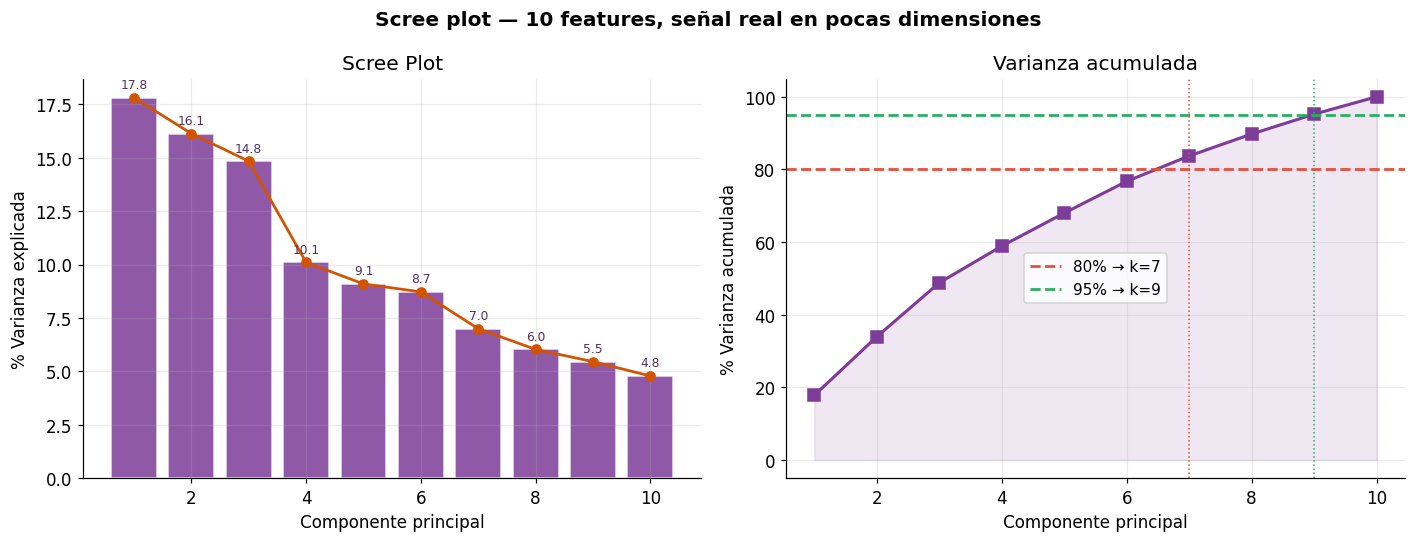

Componentes para 80% varianza: 7
Componentes para 95% varianza: 9
Reducción: 10 features → 7 PCs mantiene el 80% de la información


In [5]:
np.random.seed(SEED)
n_sc, p_sc = 300, 10
# Señal real en 4 dimensiones + ruido
Cov_sc=np.random.randn(p_sc,p_sc); Cov_sc=Cov_sc@Cov_sc.T/p_sc+np.eye(p_sc)
X_sc=np.random.multivariate_normal(np.zeros(p_sc), Cov_sc, n_sc)

pca_sc=PCA(); pca_sc.fit(StandardScaler().fit_transform(X_sc))
var_exp=pca_sc.explained_variance_ratio_
var_cum=np.cumsum(var_exp)

n_80=np.argmax(var_cum>=0.80)+1
n_95=np.argmax(var_cum>=0.95)+1

fig, axes=plt.subplots(1,2,figsize=(13,5))
ks=range(1,p_sc+1)

# Panel izquierdo: scree plot
bars=axes[0].bar(ks, var_exp*100, color='#7D3C98', alpha=0.85, edgecolor='white')
axes[0].plot(ks, var_exp*100, 'o-', color='#D35400', lw=1.8, markersize=6)
axes[0].set(xlabel='Componente principal', ylabel='% Varianza explicada',
           title='Scree Plot')
axes[0].grid(True, alpha=0.25)
for b,v in zip(bars,var_exp*100):
    if v>3:
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=8, color='#512E5F')

# Panel derecho: varianza acumulada
axes[1].plot(ks, var_cum*100, 's-', color='#7D3C98', lw=2, markersize=8)
axes[1].axhline(80, color='#E74C3C', lw=1.8, linestyle='--', label=f'80% → k={n_80}')
axes[1].axhline(95, color='#27AE60', lw=1.8, linestyle='--', label=f'95% → k={n_95}')
axes[1].axvline(n_80, color='#E74C3C', lw=1, linestyle=':')
axes[1].axvline(n_95, color='#27AE60', lw=1, linestyle=':')
axes[1].fill_between(ks, var_cum*100, alpha=0.12, color='#7D3C98')
axes[1].set(xlabel='Componente principal', ylabel='% Varianza acumulada',
           title='Varianza acumulada')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.25)

plt.suptitle('Scree plot — 10 features, señal real en pocas dimensiones', fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Componentes para 80% varianza: {n_80}')
print(f'Componentes para 95% varianza: {n_95}')
print(f'Reducción: {p_sc} features → {n_80} PCs mantiene el 80% de la información')

---
## 4. Biplot — features y observaciones en el mismo gráfico

El **biplot** muestra:
- **Puntos:** observaciones proyectadas en PC1-PC2
- **Flechas (loadings):** dirección e importancia de cada feature

Arrow larga → feature con mucho peso en esas PCs.  
Ángulo pequeño entre flechas → features correlacionadas.

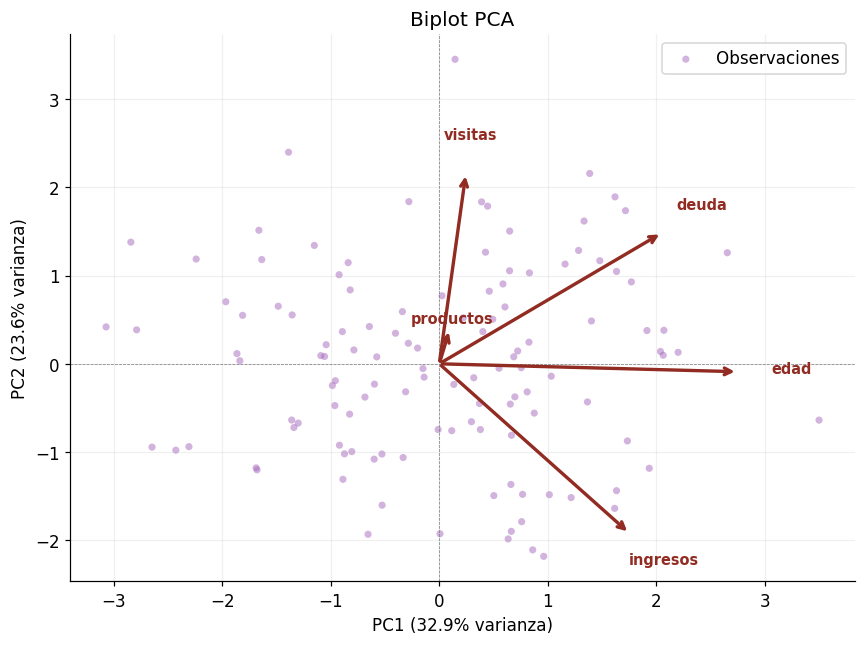

Interpretación del biplot:
  Flechas largas  → feature con alta varianza en PC1/PC2
  Ángulo pequeño  → features correlacionadas entre sí
  Ángulo = 90°    → features ortogonales (no correlacionadas)
  Ángulo = 180°   → features inversamente correlacionadas


In [ ]:
np.random.seed(SEED)
feats_bp=['ingresos','edad','deuda','productos','visitas']
n_bp=120
# Crear correlaciones interesantes
X_bp_raw=np.random.randn(n_bp,5)@np.array([
    [2.0, 1.0, 0.0, 0.0, 0.0],
    [0.0, 1.5, 0.5, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.8, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.6]
])
X_bp_sc=StandardScaler().fit_transform(X_bp_raw)
pca_bp=PCA(n_components=2)
X_bp_proj=pca_bp.fit_transform(X_bp_sc)

# Loadings escalados para biplot
loadings=pca_bp.components_.T * np.sqrt(pca_bp.explained_variance_)

fig,ax=plt.subplots(figsize=(8,6))
ax.scatter(X_bp_proj[:,0], X_bp_proj[:,1], alpha=0.5, s=22,
           color="#A969BD", edgecolors='none', label='Observaciones')

# Escalar observaciones para que queden en rango similar a loadings
scale=max(np.abs(X_bp_proj).max(), np.abs(loadings).max()*2.5) / max(np.abs(loadings).max()*3, 1)

for i,feat in enumerate(feats_bp):
    lx,ly=loadings[i,0]*3, loadings[i,1]*3
    ax.annotate('', xy=(lx,ly), xytext=(0,0),
        arrowprops=dict(arrowstyle='->', color='#922B21', lw=2.2))
    ax.text(lx*1.18, ly*1.18, feat, fontsize=9.5, color='#922B21',
            fontweight='bold', ha='center')

ax.axhline(0, color='gray', lw=0.5, linestyle='--')
ax.axvline(0, color='gray', lw=0.5, linestyle='--')
ax.set(xlabel=f'PC1 ({pca_bp.explained_variance_ratio_[0]:.1%} varianza)',
       ylabel=f'PC2 ({pca_bp.explained_variance_ratio_[1]:.1%} varianza)',
       title='Biplot PCA')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.18)
plt.tight_layout(); plt.show()

print('Interpretación del biplot:')
print('  Flechas largas  → feature con alta varianza en PC1/PC2')
print('  Ángulo pequeño  → features correlacionadas entre sí')
print('  Ángulo = 90°    → features ortogonales (no correlacionadas)')
print('  Ángulo = 180°   → features inversamente correlacionadas')

---
## 5. Aplicación: decorrelacionar datos financieros

Ejemplo completo: dataset con 8 features correlacionadas de clientes bancarios.

In [7]:
np.random.seed(SEED)
n_fin=400
feats_fin=['ingresos','deuda','antiguedad','productos','transacciones',
           'saldo_prom','mora_30d','mora_90d']
# Estructura de correlación alta (típica en datos financieros)
Sigma_fin=np.array([
    [4.0, 1.5,-0.8, 0.6, 1.2,-0.4,-1.0,-0.8],
    [1.5, 3.0, 0.5, 0.4, 0.8, 0.5, 1.5, 1.2],
    [-0.8,0.5, 2.0, 0.7, 0.5, 0.8,-0.3,-0.2],
    [0.6, 0.4, 0.7, 1.5, 0.9, 0.6,-0.2,-0.1],
    [1.2, 0.8, 0.5, 0.9, 3.0, 0.7,-0.5,-0.4],
    [-0.4,0.5, 0.8, 0.6, 0.7, 2.5, 0.4, 0.3],
    [-1.0,1.5,-0.3,-0.2,-0.5, 0.4, 4.0, 3.2],
    [-0.8,1.2,-0.2,-0.1,-0.4, 0.3, 3.2, 3.5],
])
X_fin=np.random.multivariate_normal(np.zeros(8), Sigma_fin, n_fin)

pca_fin=PCA(); pca_fin.fit(StandardScaler().fit_transform(X_fin))
var_fin=pca_fin.explained_variance_ratio_
var_cum_fin=np.cumsum(var_fin)

print('Varianza explicada por componente:')
for i,(v,c) in enumerate(zip(var_fin,var_cum_fin)):
    bar='█'*int(v*40)
    print(f'  PC{i+1}: {v:.3f} ({v*100:.1f}%)  acum={c:.3f}  {bar}')

print(f'\nParaReducir a 80%: {np.argmax(var_cum_fin>=0.80)+1} PCs de {len(feats_fin)}')
print(f'Para reducir a 95%: {np.argmax(var_cum_fin>=0.95)+1} PCs de {len(feats_fin)}')

# Alta correlación entre mora_30d y mora_90d se captura en 1 PC
print('\nNota: mora_30d y mora_90d son muy correlacionadas → 1 PC las resume.')

Varianza explicada por componente:
  PC1: 0.280 (28.0%)  acum=0.280  ███████████
  PC2: 0.268 (26.8%)  acum=0.548  ██████████
  PC3: 0.194 (19.4%)  acum=0.742  ███████
  PC4: 0.086 (8.6%)  acum=0.828  ███
  PC5: 0.077 (7.7%)  acum=0.905  ███
  PC6: 0.062 (6.2%)  acum=0.967  ██
  PC7: 0.022 (2.2%)  acum=0.990  
  PC8: 0.010 (1.0%)  acum=1.000  

ParaReducir a 80%: 4 PCs de 8
Para reducir a 95%: 6 PCs de 8

Nota: mora_30d y mora_90d son muy correlacionadas → 1 PC las resume.


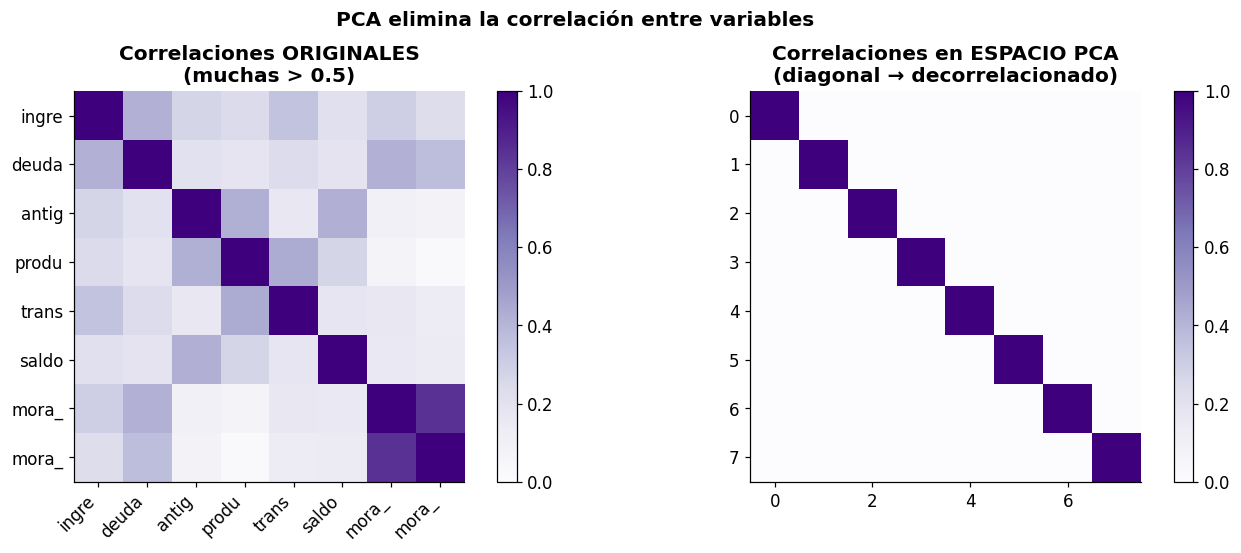

Correlación media fuera de diagonal (original): 0.2249
Correlación media fuera de diagonal (PCA):      0.0000  ← ≈ 0 ✓


In [8]:
# Correlaciones antes vs después de PCA
X_fin_sc=StandardScaler().fit_transform(X_fin)
X_fin_pca=pca_fin.transform(X_fin_sc)

corr_orig=np.corrcoef(X_fin_sc.T)
corr_pca =np.corrcoef(X_fin_pca.T)

fig,axes=plt.subplots(1,2,figsize=(13,5))
im1=axes[0].imshow(np.abs(corr_orig), cmap='Purples', vmin=0, vmax=1)
plt.colorbar(im1, ax=axes[0])
axes[0].set_xticks(range(8)); axes[0].set_yticks(range(8))
axes[0].set_xticklabels([f[:5] for f in feats_fin], rotation=45, ha='right')
axes[0].set_yticklabels([f[:5] for f in feats_fin])
axes[0].set_title('Correlaciones ORIGINALES\n(muchas > 0.5)', fontweight='bold')

im2=axes[1].imshow(np.abs(corr_pca), cmap='Purples', vmin=0, vmax=1)
plt.colorbar(im2, ax=axes[1])
axes[1].set_title('Correlaciones en ESPACIO PCA\n(diagonal → decorrelacionado)', fontweight='bold')

plt.suptitle('PCA elimina la correlación entre variables', fontweight='bold')
plt.tight_layout(); plt.show()

off_diag_orig = np.abs(corr_orig - np.eye(8)).mean()
off_diag_pca  = np.abs(corr_pca  - np.eye(8)).mean()
print(f'Correlación media fuera de diagonal (original): {off_diag_orig:.4f}')
print(f'Correlación media fuera de diagonal (PCA):      {off_diag_pca:.4f}  ← ≈ 0 ✓')

---
## Conclusiones

<div style="background:#F5EEF8;border-left:5px solid #7D3C98;padding:20px 24px;border-radius:0 8px 8px 0;">

**01 · PCA = eigendecomposición de la covarianza centrada**
Las PCs son los eigenvectors de Σ̂, ordenados por eigenvalue (varianza). SVD y eigendecomp dan el mismo resultado.

**02 · El scree plot guía cuántas PCs retener**
Buscar el codo, o usar criterio de 80%/95% de varianza acumulada. No hay una regla única.

**03 · El biplot une observaciones y features**
Flechas largas = features importantes. Ángulo entre flechas = correlación. Punto extremo = observación atípica.

</div>

---
<div style="background:#512E5F;color:white;padding:20px 24px;border-radius:8px;">
<strong>Próxima clase — Clase 11</strong><br>
Cuántas PCs retener: criterio Kaiser · Codo · Loadings e interpretación · Pipeline PCA + clasificación<br>
<em>Docente: Josef Rodriguez · Curso 8 · Módulo 4</em>
</div>